<a href="https://colab.research.google.com/github/Pravallika-B6/AI_Powered_Intelligent_Traffic_Safety_and_Emergency_Response_System/blob/main/LCR_Net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, io, gc, time, json, random, shutil, warnings
from collections import Counter
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_curve,
                             roc_auc_score, precision_recall_curve, average_precision_score)

warnings.filterwarnings("ignore")
print("TensorFlow :", tf.__version__)
print("OpenCV     :", cv2.__version__)
print("GPUs       :", tf.config.list_physical_devices("GPU") or "none (training will be slow on CPU)")

TensorFlow : 2.21.0
OpenCV     : 4.14.0
GPUs       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Not running in Colab: skipping Drive mount (paths below must exist locally).")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ---------------- Reproducibility (Section 39) ----------------
SEED = 42
def set_global_seed(seed=SEED):
    """Seed Python, NumPy and TensorFlow so runs are repeatable where practical.
    (GPU kernels can still introduce tiny non-determinism, so results may differ slightly between runs.)"""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)   # seeds all three at once, kept for safety
set_global_seed(SEED)

# ---------------- Paths ----------------
BASE_DIR   = '/content/drive/MyDrive/Colab Notebooks/datasets/data3'
OUTPUT_DIR = '/content/drive/MyDrive/LCR_Net'      # plots, csv, model copies go here
LOCAL_DIR  = '/content'                            # fast local copy of the model
CKPT_DIR   = '/content/checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)
try:
    os.makedirs(OUTPUT_DIR, exist_ok=True)
except OSError as e:
    print(f"Could not create {OUTPUT_DIR} ({e}). Falling back to /content/LCR_Net")
    OUTPUT_DIR = '/content/LCR_Net'; os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------- Data / labels ----------------
IMG_SIZE    = 224
IMG_SHAPE   = (IMG_SIZE, IMG_SIZE, 3)
CLASS_NAMES = ["Non Accident", "Accident"]          # index = label: 0 and 1
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
SPLITS      = ["train", "val", "test"]
VALID_EXT   = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# ---------------- Training ----------------
BATCH_SIZE    = 16
EPOCHS        = 60                 # upper limit; EarlyStopping normally stops sooner
LEARNING_RATE = 5e-4               # see Section 12 for the justification

# ---------------- Decision threshold (Section 28) ----------------
ACCIDENT_THRESHOLD = 0.50          # configurable; tune on VALIDATION data only, never on test

# ---------------- Video / alert (Sections 28-30) ----------------
REQUIRED_CONSECUTIVE_HITS = 3
ALERT_CONFIDENCE = 0.60            # a frame counts as a "hit" only if P(Accident) >= max(threshold, this)
VIDEO_PATH   = None                # e.g. '/content/drive/MyDrive/test_video.mp4'  (None = skip video demo)
ALERT_DIR    = os.path.join(OUTPUT_DIR, "alerts")

# ---------------- Ablation ----------------
ABLATION_SEEDS = [42]              # e.g. [42, 7, 123] to average over several runs (slower, more reliable)

print("Configuration loaded.")
print("Label mapping:", CLASS_TO_IDX)

Configuration loaded.
Label mapping: {'Non Accident': 0, 'Accident': 1}


In [ ]:
def verify_dataset(base_dir=BASE_DIR, check_decode=True):
    """Walk the dataset, count valid images, and raise a clear error if something is wrong."""
    if not os.path.isdir(base_dir):
        raise FileNotFoundError(
            f"Dataset directory not found: {base_dir}\n"
            "Check that Google Drive is mounted and that BASE_DIR is spelled correctly.")
    report, ext_counter, corrupted_all, unsupported_all, problems = {}, Counter(), [], [], []
    for split in SPLITS:
        split_dir = os.path.join(base_dir, split)
        if not os.path.isdir(split_dir):
            raise FileNotFoundError(f"Missing split folder: {split_dir}")
        report[split] = {}
        for cls in CLASS_NAMES:
            cls_dir = os.path.join(split_dir, cls)
            if not os.path.isdir(cls_dir):
                raise FileNotFoundError(f"Missing class folder: {cls_dir}  (expected names: {CLASS_NAMES})")
            valid = 0
            for f in sorted(os.listdir(cls_dir)):
                p = os.path.join(cls_dir, f)
                if not os.path.isfile(p):
                    continue
                ext = os.path.splitext(f)[1].lower()
                if ext not in VALID_EXT:
                    unsupported_all.append(p); continue
                if check_decode and cv2.imread(p, cv2.IMREAD_COLOR) is None:
                    corrupted_all.append(p); continue
                valid += 1; ext_counter[ext] += 1
            report[split][cls] = valid
            if valid == 0:
                problems.append(f"EMPTY folder (no valid images): {cls_dir}")

    names = {"train": "Training", "val": "Validation", "test": "Testing"}
    print("================ DATASET REPORT ================\n")
    total = 0
    for split in SPLITS:
        print(f"{names[split]}:")
        for cls in CLASS_NAMES:
            print(f"{cls}: {report[split][cls]}")
        total += sum(report[split].values()); print()
    print(f"Total valid images: {total}")
    print("Extensions found  :", dict(ext_counter))
    print("Unsupported files :", len(unsupported_all), "| Corrupted images:", len(corrupted_all))
    for p in unsupported_all[:10]: print("   unsupported:", p)
    for p in corrupted_all[:10]:   print("   corrupted  :", p)
    print("\nClass distribution (% Accident per split):")
    for split in SPLITS:
        n = sum(report[split].values())
        print(f"  {names[split]:<10}: {100*report[split]['Accident']/max(n,1):.1f}% Accident, "
              f"{100*report[split]['Non Accident']/max(n,1):.1f}% Non Accident")
    print("\n==================================================")
    if problems:
        raise ValueError("Dataset problems found:\n  " + "\n  ".join(problems))
    if total == 0:
        raise ValueError("Dataset is empty.")
    return report

dataset_report = verify_dataset()

================ DATASET REPORT ================

Training:
Non Accident: 422
Accident: 370

Validation:
Non Accident: 52
Accident: 46

Testing:
Non Accident: 53
Accident: 47

Total valid images: 990
Extensions found  : {'.jpg': 990}
Unsupported files : 0 | Corrupted images: 0

Class distribution (% Accident per split):
  Training  : 46.7% Accident, 53.3% Non Accident
  Validation: 46.9% Accident, 53.1% Non Accident
  Testing   : 47.0% Accident, 53.0% Non Accident



In [ ]:
def resize_rgb(img_rgb, img_size=IMG_SIZE):
    """Resize an RGB uint8 image to (img_size, img_size) and validate the shape."""
    if img_rgb is None or img_rgb.ndim != 3 or img_rgb.shape[2] != 3:
        raise ValueError(f"Invalid image shape: {None if img_rgb is None else img_rgb.shape} (expected HxWx3)")
    out = cv2.resize(img_rgb, (img_size, img_size), interpolation=cv2.INTER_AREA)
    if out.shape != (img_size, img_size, 3):
        raise ValueError(f"Resize produced unexpected shape {out.shape}")
    return out

def load_image_rgb(path, img_size=IMG_SIZE):
    """Load ONE image file -> uint8 RGB array of shape (224,224,3). Raises a clear error on failure."""
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Image not found: {path}")
    if os.path.splitext(path)[1].lower() not in VALID_EXT:
        raise ValueError(f"Unsupported image format: {path} (supported: {VALID_EXT})")
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)          # BGR, 3 channels, uint8 (None if corrupted)
    if bgr is None:
        raise ValueError(f"Corrupted or unreadable image: {path}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)          # BGR -> RGB
    return resize_rgb(rgb, img_size)

def normalize_image(img_uint8):
    """uint8 [0,255] -> float32 [0,1]. The ONLY place pixel scaling happens (for numpy inputs)."""
    return img_uint8.astype(np.float32) / 255.0

def preprocess_image(path):
    """Full test-time preprocessing for one file (used by predict_single_image)."""
    return normalize_image(load_image_rgb(path))

def load_split(split, base_dir=BASE_DIR):
    """Load a whole split -> (X uint8 [N,224,224,3], y int [N], paths). Corrupted images are skipped and reported."""
    X, y, paths, skipped = [], [], [], []
    for cls in CLASS_NAMES:
        cls_dir = os.path.join(base_dir, split, cls)
        for f in sorted(os.listdir(cls_dir)):
            p = os.path.join(cls_dir, f)
            if not os.path.isfile(p) or os.path.splitext(f)[1].lower() not in VALID_EXT:
                continue
            try:
                X.append(load_image_rgb(p)); y.append(CLASS_TO_IDX[cls]); paths.append(p)
            except (ValueError, FileNotFoundError) as e:
                skipped.append(str(e))
    if not X:
        raise ValueError(f"No valid images loaded for split '{split}'.")
    for s in skipped: print("  [skipped]", s)
    return np.stack(X).astype(np.uint8), np.array(y, dtype=np.int32), paths

X_train, y_train, train_paths = load_split("train")
X_val,   y_val,   val_paths   = load_split("val")
X_test,  y_test,  test_paths  = load_split("test")
for name, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    print(f"{name:<5}: X={X.shape} dtype={X.dtype} | Non_Accident={(y==0).sum()} Accident={(y==1).sum()}")

train: X=(792, 224, 224, 3) dtype=uint8 | Non_Accident=422 Accident=370
val  : X=(98, 224, 224, 3) dtype=uint8 | Non_Accident=52 Accident=46
test : X=(100, 224, 224, 3) dtype=uint8 | Non_Accident=53 Accident=47


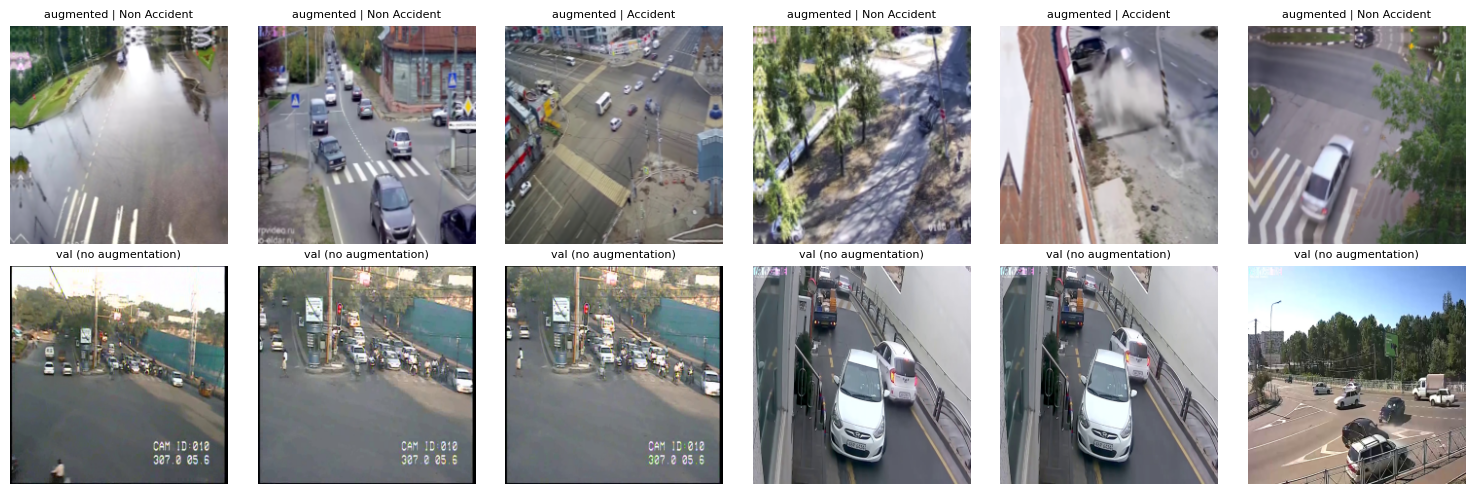

In [ ]:
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.04),               # about +/- 14 degrees
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10),
], name="train_augmentation")

AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(X, y, training):
    """tf.data pipeline. training=True -> shuffle + augmentation. Otherwise deterministic order, no augmentation."""
    ds = tf.data.Dataset.from_tensor_slices((X, y.astype(np.float32)))
    if training:
        ds = ds.shuffle(len(X), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.map(lambda a, b: (tf.cast(a, tf.float32) / 255.0, b), num_parallel_calls=AUTOTUNE)   # normalization (once)
    if training:
        ds = ds.map(lambda a, b: (augmentation(a, training=True), b), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds = make_dataset(X_train, y_train, training=True)
val_ds   = make_dataset(X_val,   y_val,   training=False)
test_ds  = make_dataset(X_test,  y_test,  training=False)

# Visual check: augmented training images and the raw (non-augmented) versions.
xb, yb = next(iter(train_ds))
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i in range(6):
    axes[0, i].imshow(np.clip(xb[i].numpy(), 0, 1)); axes[0, i].set_title(f"augmented | {CLASS_NAMES[int(yb[i])]}", fontsize=8); axes[0, i].axis("off")
    axes[1, i].imshow(X_val[i]);                      axes[1, i].set_title("val (no augmentation)", fontsize=8);        axes[1, i].axis("off")
plt.tight_layout(); plt.show()

In [ ]:
cw = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]), y=y_train)
class_weights = {0: float(cw[0]), 1: float(cw[1])}
print("Class weights (used during training):")
for k, v in class_weights.items():
    print(f"  {CLASS_NAMES[k]} ({k}): {v:.4f}")

Class weights (used during training):
  Non Accident (0): 0.9384
  Accident (1): 1.0703


In [ ]:
def standard_conv_block(filters, stride=1, name=None):
    """Conv3x3 -> BN -> ReLU (standard convolution; used for the stem and for the 'no-DSC' ablation variants)."""
    return tf.keras.Sequential([
        layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
    ], name=name)

def depthwise_separable_block(filters, stride=1, name=None):
    """Depthwise 3x3 -> BN -> ReLU -> Pointwise 1x1 -> BN -> ReLU.
    Depthwise = one spatial filter per channel (spatial filtering). Pointwise = 1x1 conv mixing channels."""
    return tf.keras.Sequential([
        layers.DepthwiseConv2D(3, strides=stride, padding="same", use_bias=False),
        layers.BatchNormalization(momentum=0.9),
        layers.ReLU(),
        layers.Conv2D(filters, 1, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
    ], name=name)

def lightweight_conv_block(filters, use_dsc=True, stride=1, name=None):
    """One 'lightweight feature block' (stride 1) or 'downsampling block' (stride 2).
    use_dsc=True  -> depthwise separable conv (cheap).   use_dsc=False -> standard conv (used for ablation Model 1)."""
    return depthwise_separable_block(filters, stride, name) if use_dsc else standard_conv_block(filters, stride, name)

def pointwise_block(filters, name=None):
    """1x1 Conv -> BN -> ReLU (channel mixing only)."""
    return tf.keras.Sequential([layers.Conv2D(filters, 1, use_bias=False), layers.BatchNormalization(), layers.ReLU()], name=name)

In [ ]:
@tf.keras.utils.register_keras_serializable(package="LCR")
class SpatialRelationModule(layers.Layer):
    def __init__(self, key_dim=None, pool_size=2, **kwargs):
        super().__init__(**kwargs)
        self.key_dim, self.pool_size = key_dim, pool_size

    def build(self, input_shape):
        _, H, W, C = input_shape
        self.H, self.W, self.C = int(H), int(W), int(C)
        self.d = self.key_dim or max(self.C // 4, 8)
        Hp, Wp = -(-self.H // self.pool_size), -(-self.W // self.pool_size)   # ceil division
        self.M = Hp * Wp
        self.pool   = layers.AveragePooling2D(self.pool_size, padding="same")
        self.q_proj = layers.Conv2D(self.d, 1, use_bias=False)    # query projection (1x1 conv)
        self.k_proj = layers.Conv2D(self.d, 1, use_bias=False)    # key projection
        self.v_proj = layers.Conv2D(self.C, 1, use_bias=False)    # value projection
        self.out_proj = layers.Conv2D(self.C, 1, use_bias=False)
        self.out_bn = layers.BatchNormalization(momentum=0.9)
        self.q_proj.build((None, self.H, self.W, self.C))
        for l in (self.k_proj, self.v_proj):
            l.build((None, Hp, Wp, self.C))
        self.out_proj.build((None, self.H, self.W, self.C))
        self.out_bn.build((None, self.H, self.W, self.C))
        self.pos_embed = self.add_weight(name="pos_embed", shape=(1, self.M, self.d),
                                         initializer=tf.keras.initializers.RandomNormal(stddev=0.02))
        super().build(input_shape)

    def call(self, x, training=False):
        q = tf.reshape(self.q_proj(x), (-1, self.H * self.W, self.d))              # (B, N, d)
        xp = self.pool(x)                                                           # (B, Hp, Wp, C)
        k = tf.reshape(self.k_proj(xp), (-1, self.M, self.d)) + self.pos_embed     # (B, M, d)
        v = tf.reshape(self.v_proj(xp), (-1, self.M, self.C))                      # (B, M, C)
        attn = tf.nn.softmax(tf.matmul(q, k, transpose_b=True) / (self.d ** 0.5), axis=-1)   # (B, N, M) relation weights
        rel = tf.reshape(tf.matmul(attn, v), (-1, self.H, self.W, self.C))         # relation-enhanced features
        return self.out_bn(self.out_proj(rel), training=training)

    def get_config(self):
        cfg = super().get_config(); cfg.update(key_dim=self.key_dim, pool_size=self.pool_size); return cfg

In [ ]:
@tf.keras.utils.register_keras_serializable(package="LCR")
class RelationFusionModule(layers.Layer):
    def build(self, input_shape):
        s_feat, s_rel = input_shape
        C = int(s_feat[-1])
        self.conv = layers.Conv2D(C, 1, use_bias=False)
        self.bn = layers.BatchNormalization(momentum=0.9)
        self.act = layers.ReLU()
        self.conv.build((None, s_feat[1], s_feat[2], int(s_feat[-1]) + int(s_rel[-1])))
        self.bn.build((None, s_feat[1], s_feat[2], C))
        super().build(input_shape)

    def call(self, inputs, training=False):
        feat, rel = inputs
        fused = tf.concat([feat, rel], axis=-1)                       # original + relation features
        return self.act(self.bn(self.conv(fused), training=training))  # learned 1x1 mixing

    def get_config(self):
        return super().get_config()

In [ ]:
@tf.keras.utils.register_keras_serializable(package="LCR")
class LightweightAttention(layers.Layer):
    def __init__(self, reduction=8, spatial_kernel=7, **kwargs):
        super().__init__(**kwargs)
        self.reduction, self.spatial_kernel = reduction, spatial_kernel

    def build(self, input_shape):
        _, H, W, C = input_shape
        hidden = max(int(C) // self.reduction, 4)
        self.gap = layers.GlobalAveragePooling2D(keepdims=True)
        self.fc1 = layers.Dense(hidden, activation="relu")
        self.fc2 = layers.Dense(int(C), activation="sigmoid")
        self.spatial_conv = layers.Conv2D(1, self.spatial_kernel, padding="same", activation="sigmoid")
        self.fc1.build((None, 1, 1, int(C)))
        self.fc2.build((None, 1, 1, hidden))
        self.spatial_conv.build((None, H, W, 2))
        super().build(input_shape)

    def call(self, x):
        ch = self.fc2(self.fc1(self.gap(x)))                                  # (B,1,1,C) channel weights
        x = x * ch
        avg = tf.reduce_mean(x, axis=-1, keepdims=True)
        mx  = tf.reduce_max(x, axis=-1, keepdims=True)
        sp = self.spatial_conv(tf.concat([avg, mx], axis=-1))                # (B,H,W,1) spatial weights
        return x * sp

    def get_config(self):
        cfg = super().get_config(); cfg.update(reduction=self.reduction, spatial_kernel=self.spatial_kernel); return cfg

In [ ]:
# Create pre-trained backbone
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE, include_top=False, weights='imagenet'
)
base_model.trainable = False  # Freeze ImageNet weights

# Build transfer learning model
inputs = layers.Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)
x = LightweightAttention()(x)  # Retain your custom attention module
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

lcr_net = tf.keras.Model(inputs=inputs, outputs=outputs, name="LCRNet_MobileNetV2")

# Verify model build
lcr_net.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "LCRNet_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lightweight_attention           │ (None, 7, 7, 1280)     │       411,139 │
│ (LightweightAttention)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,670,404 (10.19 MB)

 Trainable params: 412,420 (1.57 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
set_global_seed(SEED)
lcr_net = build_lcr_net(input_shape=IMG_SHAPE, num_classes=1, dropout_rate=0.3)
lcr_net.summary()
tot, trn, non = count_params(lcr_net)
print("\n========== LCR-Net parameters ==========")
print(f"Total parameters        : {tot:,}")
print(f"Trainable parameters    : {trn:,}")
print(f"Non-trainable parameters: {non:,}   (BatchNorm moving statistics)")
print("========================================")

Model: "lcr_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ stem (Sequential)               │ (1, 112, 112, 32)      │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s1_block (Sequential)           │ (1, 112, 112, 32)      │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s1_down (Sequential)            │ (1, 56, 56, 64)        │         2,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s2_block (Sequential)           │ (1, 56, 56, 64)        │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s2_down (Sequential)            │ (1, 28, 28, 128)       │         9,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s3_block (Sequential)           │ (1, 28, 28, 128)       │        18,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s3_down (Sequential)            │ (1, 14, 14, 128)       │        18,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_6             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_7             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multilevel_merge (Sequential)   │ (1, 14, 14, 128)       │        41,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_relation                │ ?                      │        43,040 │
│ (SpatialRelationModule)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relation_fusion                 │ ?                      │        33,280 │
│ (RelationFusionModule)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention                       │ ?                      │         4,339 │
│ (LightweightAttention)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (1, 64)                │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (1, 1)                 │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 187,572 (732.70 KB)

 Trainable params: 184,756 (721.70 KB)

 Non-trainable params: 2,816 (11.00 KB)


========== LCR-Net parameters ==========
Total parameters        : 187,572
Trainable parameters    : 184,756
Non-trainable parameters: 2,816   (BatchNorm moving statistics)


In [ ]:
def compile_model(model, lr=LEARNING_RATE):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy",
                 tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.Recall(name="recall")])
    return model

compile_model(lcr_net)
print("Model compiled.")

Model compiled.


In [ ]:
def train_model(model, run_name, epochs=EPOCHS, verbose=1):
    ckpt_path = os.path.join(CKPT_DIR, f"{run_name}.weights.h5")
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True,
                                           save_weights_only=True, verbose=0),
    ]
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs,
                        class_weight=class_weights, callbacks=callbacks, verbose=verbose)
    return history, ckpt_path

t0 = time.time()
history, lcr_ckpt = train_model(lcr_net, "lcr_net_main")
print(f"\nTraining finished in {(time.time()-t0)/60:.1f} min | epochs run: {len(history.history['loss'])}")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")

Epoch 1/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 66s 881ms/step - accuracy: 0.5783 - loss: 0.6801 - precision: 0.5506 - recall: 0.5297 - val_accuracy: 0.4694 - val_loss: 0.6971 - val_precision: 0.4694 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 2/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 264ms/step - accuracy: 0.6010 - loss: 0.6571 - precision: 0.5646 - recall: 0.6378 - val_accuracy: 0.5306 - val_loss: 0.7022 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 3/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 263ms/step - accuracy: 0.6174 - loss: 0.6541 - precision: 0.6120 - recall: 0.4946 - val_accuracy: 0.5306 - val_loss: 0.9041 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 4/60
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.6656 - loss: 0.6108 - precision: 0.6507 - recall: 0.5912
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 243ms/step - accuracy: 0.6477 - loss:

In [ ]:
# Predict probabilities directly using Keras
p_tr = lcr_net.predict(train_ds)
p_va = lcr_net.predict(val_ds)

print("train probs  min/mean/max:", p_tr.min(), p_tr.mean(), p_tr.max())
print("val probs    min/mean/max:", p_va.min(), p_va.mean(), p_va.max())
print("train acc (inference mode):", ((p_tr.flatten() >= 0.5) == y_train).mean())
print("val acc   (inference mode):", ((p_va.flatten() >= 0.5) == y_val).mean())

50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 288ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 266ms/step
train probs  min/mean/max: 0.4926986 0.52028346 0.53011596
val probs    min/mean/max: 0.5121867 0.52044535 0.5239839
train acc (inference mode): 0.4684343434343434
val acc   (inference mode): 0.46938775510204084


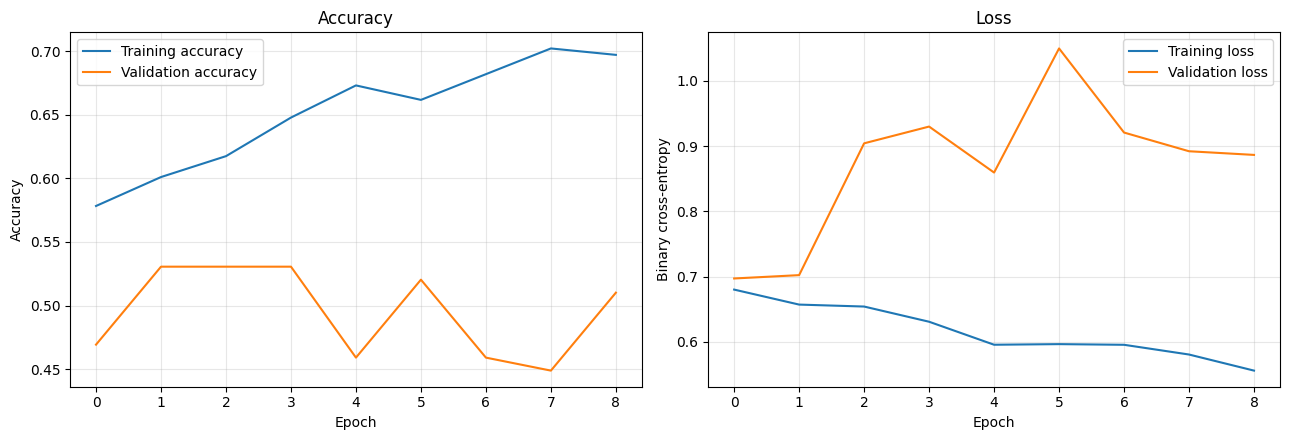

In [ ]:
def plot_history(history, save_path=None):
    h = history.history
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    ax[0].plot(h["accuracy"], label="Training accuracy"); ax[0].plot(h["val_accuracy"], label="Validation accuracy")
    ax[0].set_title("Accuracy"); ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Accuracy"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h["loss"], label="Training loss"); ax[1].plot(h["val_loss"], label="Validation loss")
    ax[1].set_title("Loss"); ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Binary cross-entropy"); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

plot_history(history, os.path.join(OUTPUT_DIR, "training_history.png"))

In [ ]:
def predict_probs(model, X):
    """P(Accident) for an array of uint8 images (same normalization as training: /255, no augmentation)."""
    ds = make_dataset(X, np.zeros(len(X), dtype=np.int32), training=False)
    return model.predict(ds, verbose=0).ravel()

def metrics_from_probs(y_true, probs, thr=ACCIDENT_THRESHOLD):
    y_pred = (probs >= thr).astype(int)
    return dict(Accuracy=accuracy_score(y_true, y_pred),
                Precision=precision_score(y_true, y_pred, zero_division=0),
                Recall=recall_score(y_true, y_pred, zero_division=0),
                F1=f1_score(y_true, y_pred, zero_division=0),
                ROC_AUC=roc_auc_score(y_true, probs) if len(np.unique(y_true)) > 1 else np.nan)

test_probs = predict_probs(lcr_net, X_test)
val_probs  = predict_probs(lcr_net, X_val)
test_pred  = (test_probs >= ACCIDENT_THRESHOLD).astype(int)
test_metrics = metrics_from_probs(y_test, test_probs)

print(f"Decision threshold: {ACCIDENT_THRESHOLD}")
print("\n===== LCR-Net TEST RESULTS =====")
for k, v in test_metrics.items():
    print(f"{k:<10}: {v:.4f}")

Decision threshold: 0.5

===== LCR-Net TEST RESULTS =====
Accuracy  : 0.4700
Precision : 0.4700
Recall    : 1.0000
F1        : 0.6395
ROC_AUC   : 0.5749


In [ ]:
print(classification_report(y_test, test_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))

              precision    recall  f1-score   support

Non Accident     0.0000    0.0000    0.0000        53
    Accident     0.4700    1.0000    0.6395        47

    accuracy                         0.4700       100
   macro avg     0.2350    0.5000    0.3197       100
weighted avg     0.2209    0.4700    0.3005       100



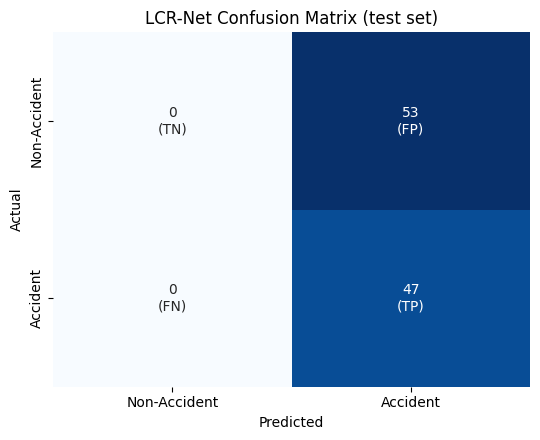

TN=0  FP=53  FN=0  TP=47
Missed accidents (FN): 0 of 47 real accidents | False alarms (FP): 53 of 53 normal images


In [ ]:
cm = confusion_matrix(y_test, test_pred, labels=[0, 1])
TN, FP, FN, TP = cm.ravel()
annot = np.array([[f"{TN}\n(TN)", f"{FP}\n(FP)"], [f"{FN}\n(FN)", f"{TP}\n(TP)"]])
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", cbar=False,
            xticklabels=["Non-Accident", "Accident"], yticklabels=["Non-Accident", "Accident"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("LCR-Net Confusion Matrix (test set)")
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150, bbox_inches="tight"); plt.show()
print(f"TN={TN}  FP={FP}  FN={FN}  TP={TP}")
print(f"Missed accidents (FN): {FN} of {FN+TP} real accidents | False alarms (FP): {FP} of {FP+TN} normal images")

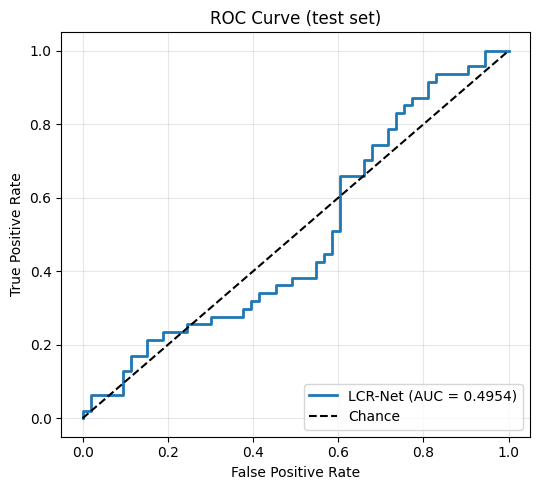

ROC-AUC: 0.4954


In [ ]:
fpr, tpr, roc_thr = roc_curve(y_test, test_probs)
auc = roc_auc_score(y_test, test_probs)
plt.figure(figsize=(5.5, 5))
plt.plot(fpr, tpr, lw=2, label=f"LCR-Net (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC Curve (test set)")
plt.legend(loc="lower right"); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "roc_curve.png"), dpi=150, bbox_inches="tight"); plt.show()
print(f"ROC-AUC: {auc:.4f}")

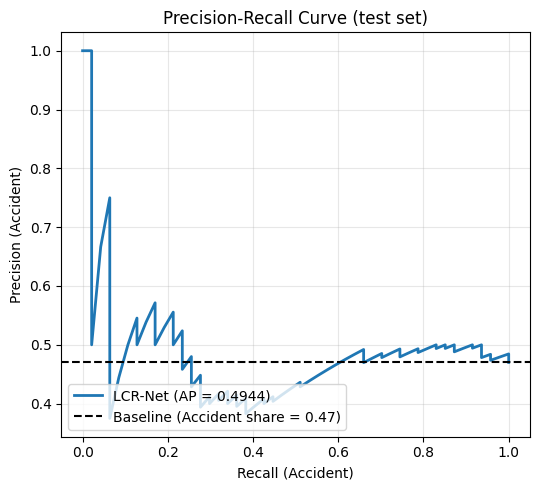

Threshold study on the VALIDATION set:
   Threshold  Precision  Recall      F1  FalseAlarms  MissedAccidents
0        0.2     0.4694     1.0  0.6389           52                0
1        0.3     0.4694     1.0  0.6389           52                0
2        0.4     0.4694     1.0  0.6389           52                0
3        0.5     0.0000     0.0  0.0000            0               46
4        0.6     0.0000     0.0  0.0000            0               46
5        0.7     0.0000     0.0  0.0000            0               46
6        0.8     0.0000     0.0  0.0000            0               46


In [ ]:
prec, rec, _ = precision_recall_curve(y_test, test_probs)
ap = average_precision_score(y_test, test_probs)
plt.figure(figsize=(5.5, 5))
plt.plot(rec, prec, lw=2, label=f"LCR-Net (AP = {ap:.4f})")
plt.axhline(y_test.mean(), color="k", ls="--", label=f"Baseline (Accident share = {y_test.mean():.2f})")
plt.xlabel("Recall (Accident)"); plt.ylabel("Precision (Accident)"); plt.title("Precision-Recall Curve (test set)")
plt.legend(loc="lower left"); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "precision_recall_curve.png"), dpi=150, bbox_inches="tight"); plt.show()

rows = []
for thr in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    yp = (val_probs >= thr).astype(int)
    c = confusion_matrix(y_val, yp, labels=[0, 1]); tn, fp, fn, tp = c.ravel()
    rows.append(dict(Threshold=thr, Precision=precision_score(y_val, yp, zero_division=0),
                     Recall=recall_score(y_val, yp, zero_division=0), F1=f1_score(y_val, yp, zero_division=0),
                     FalseAlarms=fp, MissedAccidents=fn))
val_threshold_table = pd.DataFrame(rows)
print("Threshold study on the VALIDATION set:")
display(val_threshold_table.round(4)) if "display" in globals() else print(val_threshold_table.round(4))

In [ ]:
rep = classification_report(y_test, test_pred, target_names=CLASS_NAMES, output_dict=True, zero_division=0)
print("=========== ACCIDENT CLASS (test set) ===========")
print(f"Accident Precision: {rep['Accident']['precision']:.4f}")
print(f"Accident Recall   : {rep['Accident']['recall']:.4f}")
print(f"Accident F1-score : {rep['Accident']['f1-score']:.4f}")
print("=================================================")

=========== ACCIDENT CLASS (test set) ===========
Accident Precision: 0.4700
Accident Recall   : 1.0000
Accident F1-score : 0.6395


Prediction: Accident
Confidence: 52.11%   (P(Accident) = 52.11%, threshold = 0.5)


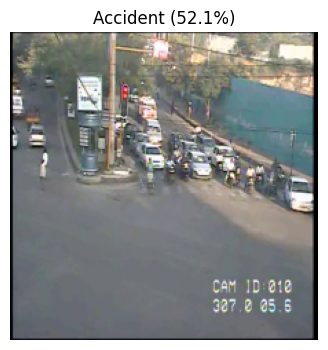

(actual label of that image: Non Accident )


In [ ]:
def predict_single_image(image_path, model=None, threshold=None, show=True):
    """Load -> resize 224x224 -> same preprocessing as test -> predict -> class + confidence."""
    model = model or lcr_net
    threshold = ACCIDENT_THRESHOLD if threshold is None else threshold
    x = preprocess_image(image_path)                              # RGB, 224x224, float32 [0,1]
    prob = float(model(x[None, ...], training=False).numpy().ravel()[0])    # P(Accident) from sigmoid
    label = "Accident" if prob >= threshold else "Non_Accident"
    confidence = prob if label == "Accident" else 1.0 - prob       # confidence in the predicted class
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence*100:.2f}%   (P(Accident) = {prob*100:.2f}%, threshold = {threshold})")
    if show:
        plt.figure(figsize=(4, 4)); plt.imshow(load_image_rgb(image_path)); plt.axis("off")
        plt.title(f"{label} ({confidence*100:.1f}%)"); plt.show()
    return label, confidence, prob

_ = predict_single_image(test_paths[0])
print("(actual label of that image:", CLASS_NAMES[y_test[0]], ")")

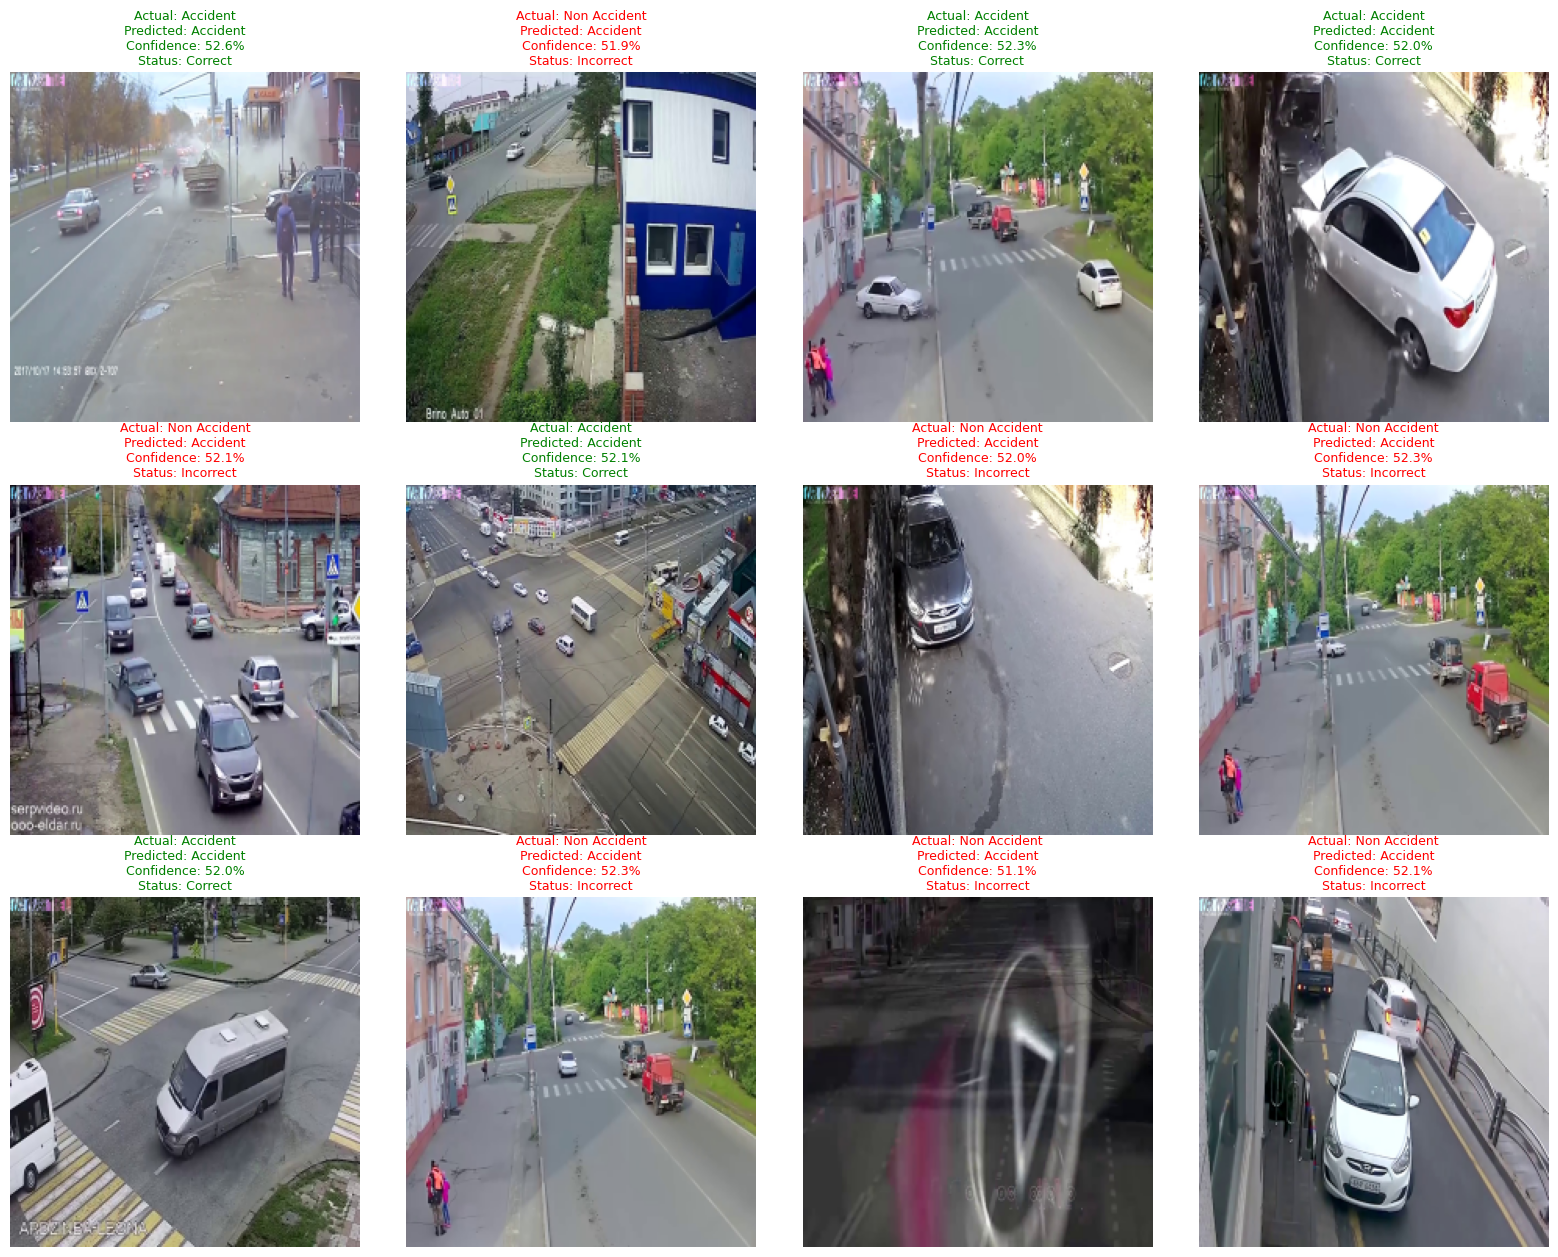

In [ ]:
def show_random_predictions(n=12, cols=4, seed=None):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X_test), size=min(n, len(X_test)), replace=False)
    rows_ = int(np.ceil(len(idx) / cols))
    plt.figure(figsize=(4 * cols, 4.2 * rows_))
    for i, j in enumerate(idx):
        prob = test_probs[j]; pred = int(prob >= ACCIDENT_THRESHOLD)
        conf = prob if pred == 1 else 1 - prob
        ok = pred == y_test[j]
        plt.subplot(rows_, cols, i + 1); plt.imshow(X_test[j]); plt.axis("off")
        plt.title(f"Actual: {CLASS_NAMES[y_test[j]]}\nPredicted: {CLASS_NAMES[pred]}\nConfidence: {conf*100:.1f}%\n"
                  f"Status: {'Correct' if ok else 'Incorrect'}", fontsize=9, color="green" if ok else "red")
    plt.tight_layout(); plt.show()

show_random_predictions(12)

False Positives (normal predicted as accident): 53
False Negatives (accident missed)             : 0


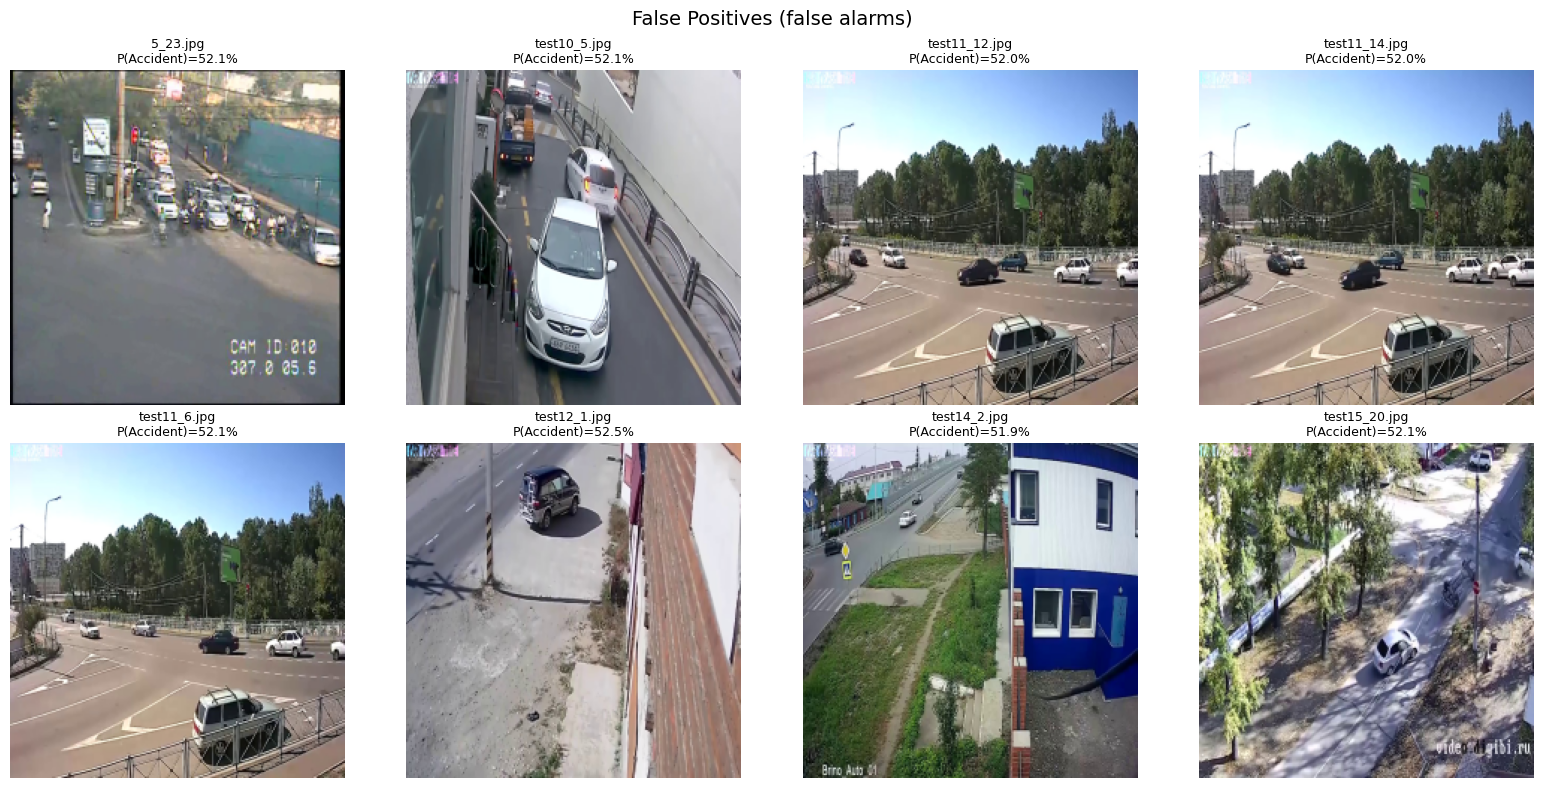

No False Negatives (missed accidents).


In [ ]:
fp_idx = np.where((y_test == 0) & (test_pred == 1))[0]
fn_idx = np.where((y_test == 1) & (test_pred == 0))[0]
print(f"False Positives (normal predicted as accident): {len(fp_idx)}")
print(f"False Negatives (accident missed)             : {len(fn_idx)}")

def show_errors(indices, title, max_n=8, cols=4):
    if len(indices) == 0:
        print(f"No {title}."); return
    indices = indices[:max_n]; rows_ = int(np.ceil(len(indices) / cols))
    plt.figure(figsize=(4 * cols, 4 * rows_))
    for i, j in enumerate(indices):
        plt.subplot(rows_, cols, i + 1); plt.imshow(X_test[j]); plt.axis("off")
        plt.title(f"{os.path.basename(test_paths[j])[:22]}\nP(Accident)={test_probs[j]*100:.1f}%", fontsize=9)
    plt.suptitle(title, fontsize=14); plt.tight_layout(); plt.show()

show_errors(fp_idx, "False Positives (false alarms)")
show_errors(fn_idx, "False Negatives (missed accidents)")

In [ ]:
def measure_cpu_inference(model, X, n=50, warmup=5):
    n = min(n, len(X)); imgs = normalize_image(X[:n])
    times = []
    with tf.device("/CPU:0"):
        for i in range(min(warmup, n)):
            model(imgs[i:i+1], training=False)
        for i in range(n):
            t = time.perf_counter(); out = model(imgs[i:i+1], training=False); out.numpy()
            times.append((time.perf_counter() - t) * 1000)
    return float(np.mean(times)), float(np.std(times)), n

# Save once locally so the real file size can be measured (also used in Section 26).
LOCAL_MODEL_PATH = os.path.join(LOCAL_DIR, "best_lcr_net.keras")
try:
    lcr_net.save(LOCAL_MODEL_PATH)
    model_size_mb = os.path.getsize(LOCAL_MODEL_PATH) / (1024 ** 2)
except Exception as e:
    print("Model save failed:", e); model_size_mb = float("nan")
mean_ms, std_ms, n_timed = measure_cpu_inference(lcr_net, X_test)
tot, trn, non = count_params(lcr_net)
print("========== LCR-Net efficiency ==========")
print(f"Total parameters       : {tot:,}")
print(f"Trainable parameters   : {trn:,}")
print(f"Model file size        : {model_size_mb:.2f} MB")
print(f"Avg CPU inference time : {mean_ms:.2f} ms/image (std {std_ms:.2f}, {n_timed} images, batch=1)")
print("========================================")

========== LCR-Net efficiency ==========
Total parameters       : 187,572
Trainable parameters   : 184,756
Model file size        : 2.35 MB
Avg CPU inference time : 199.61 ms/image (std 76.85, 50 images, batch=1)


In [ ]:
def build_simple_cnn(dropout_rate=0.3):
    return tf.keras.Sequential([
        layers.Input(IMG_SHAPE),
        layers.Conv2D(32, 3, padding="same", activation="relu"), layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"), layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"), layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation="relu"), layers.Dropout(dropout_rate),
        layers.Dense(1, activation="sigmoid")], name="simple_cnn")

def evaluate_model(model, name):
    """Evaluate one trained model on val and test. Returns one results row."""
    pv, pt = predict_probs(model, X_val), predict_probs(model, X_test)
    mt, mv = metrics_from_probs(y_test, pt), metrics_from_probs(y_val, pv)
    return dict(Model=name, Accuracy=mt["Accuracy"], Precision=mt["Precision"], Recall=mt["Recall"],
                F1=mt["F1"], ROC_AUC=mt["ROC_AUC"], Val_F1=mv["F1"], Parameters=int(model.count_params()))

set_global_seed(SEED)
simple_cnn = compile_model(build_simple_cnn())
hist_simple, _ = train_model(simple_cnn, "simple_cnn", verbose=2)
row_simple = evaluate_model(simple_cnn, "Simple CNN")
row_lcr    = evaluate_model(lcr_net, "LCR-Net")
baseline_df = pd.DataFrame([row_simple, row_lcr])
print("\nBaseline comparison (test set, threshold = %.2f):" % ACCIDENT_THRESHOLD)
print(baseline_df.round(4).to_string(index=False))
baseline_df.to_csv(os.path.join(OUTPUT_DIR, "baseline_comparison.csv"), index=False)

Epoch 1/60
50/50 - 34s - 681ms/step - accuracy: 0.4760 - loss: 0.6940 - precision: 0.4684 - recall: 0.9000 - val_accuracy: 0.4694 - val_loss: 0.6936 - val_precision: 0.4694 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 2/60
50/50 - 29s - 578ms/step - accuracy: 0.4823 - loss: 0.6932 - precision: 0.4597 - recall: 0.6162 - val_accuracy: 0.4694 - val_loss: 0.6940 - val_precision: 0.4694 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 3/60
50/50 - 14s - 283ms/step - accuracy: 0.4861 - loss: 0.6933 - precision: 0.4712 - recall: 0.8189 - val_accuracy: 0.4694 - val_loss: 0.6937 - val_precision: 0.4694 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 4/60
50/50 - 20s - 401ms/step - accuracy: 0.4672 - loss: 0.6941 - precision: 0.4658 - recall: 0.9568 - val_accuracy: 0.4694 - val_loss: 0.6934 - val_precision: 0.4694 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 5/60
50/50 - 20s - 408ms/step - accuracy: 0.4811 - loss: 0.6923 - precision: 0.4732 - recall: 0.9784 - val


>>> Model 1: Lightweight CNN only | seed 42
Epoch 1/60
50/50 - 47s - 935ms/step - accuracy: 0.5391 - loss: 0.7070 - precision: 0.5061 - recall: 0.5595 - val_accuracy: 0.5306 - val_loss: 0.6910 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 2/60
50/50 - 18s - 358ms/step - accuracy: 0.5694 - loss: 0.6920 - precision: 0.5460 - recall: 0.4649 - val_accuracy: 0.5306 - val_loss: 0.6895 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 3/60
50/50 - 13s - 269ms/step - accuracy: 0.6124 - loss: 0.6707 - precision: 0.5822 - recall: 0.6027 - val_accuracy: 0.4592 - val_loss: 0.6940 - val_precision: 0.4639 - val_recall: 0.9783 - learning_rate: 5.0000e-04
Epoch 4/60
50/50 - 19s - 380ms/step - accuracy: 0.5821 - loss: 0.6777 - precision: 0.5520 - recall: 0.5595 - val_accuracy: 0.5306 - val_loss: 0.8569 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 5/60

Epoch 5: ReduceLROnPlateau redu

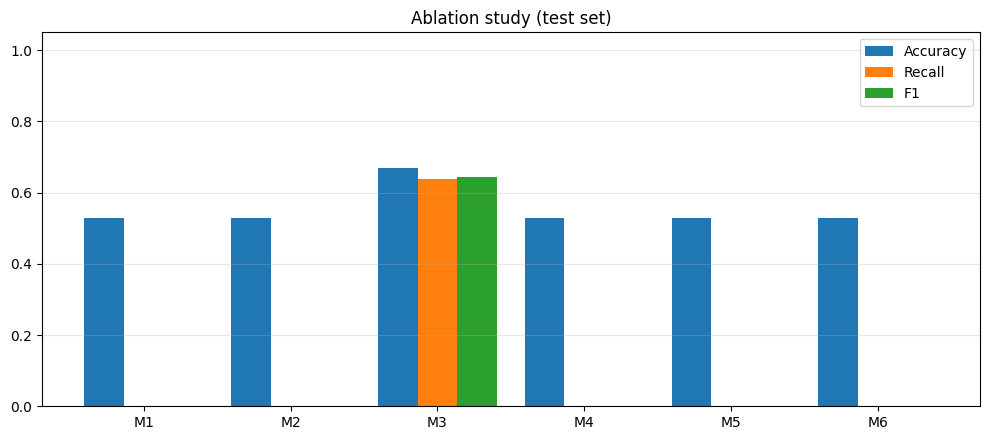

In [ ]:
OFF = dict(use_dsc=False, use_relation=False, use_fusion=False, use_attention=False, use_multilevel=False)
ABLATION_CONFIGS = [
    ("Model 1: Lightweight CNN only",             {**OFF}),
    ("Model 2: + Depthwise Separable Conv",       {**OFF, "use_dsc": True}),
    ("Model 3: + Spatial Relation",               {**OFF, "use_dsc": True, "use_relation": True}),
    ("Model 4: + Relation Fusion",                {**OFF, "use_dsc": True, "use_relation": True, "use_fusion": True}),
    ("Model 5: + Attention",                      {**OFF, "use_dsc": True, "use_relation": True, "use_fusion": True, "use_attention": True}),
    ("Model 6: Complete LCR-Net (+ Multi-level)", {**OFF, "use_dsc": True, "use_relation": True, "use_fusion": True, "use_attention": True, "use_multilevel": True}),
]

ablation_rows = []
for seed in ABLATION_SEEDS:
    for name, flags in ABLATION_CONFIGS:
        print(f"\n>>> {name} | seed {seed}")
        set_global_seed(seed)
        m = compile_model(build_lcr_net(input_shape=IMG_SHAPE, num_classes=1, dropout_rate=0.3, name="ablation_model", **flags))
        train_model(m, f"ablation_{name[:7].replace(' ', '')}_{seed}", verbose=2)
        r = evaluate_model(m, name); r["Seed"] = seed
        ablation_rows.append(r)
        del m; gc.collect()

ablation_raw = pd.DataFrame(ablation_rows)
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "Val_F1"]
ablation_df = ablation_raw.groupby("Model", sort=False).agg({**{c: "mean" for c in metric_cols}, "Parameters": "first"}).reset_index()
print("\n========== ABLATION STUDY (test set; mean over seeds %s) ==========" % ABLATION_SEEDS)
print(ablation_df.round(4).to_string(index=False))
if len(ABLATION_SEEDS) > 1:
    print("\nStd over seeds:"); print(ablation_raw.groupby("Model", sort=False)[metric_cols].std().round(4))
ablation_raw.to_csv(os.path.join(OUTPUT_DIR, "ablation_raw.csv"), index=False)
ablation_df.to_csv(os.path.join(OUTPUT_DIR, "ablation_results.csv"), index=False)

plt.figure(figsize=(10, 4.5))
x = np.arange(len(ablation_df)); w = 0.27
plt.bar(x - w, ablation_df["Accuracy"], w, label="Accuracy"); plt.bar(x, ablation_df["Recall"], w, label="Recall"); plt.bar(x + w, ablation_df["F1"], w, label="F1")
plt.xticks(x, [f"M{i+1}" for i in range(len(ablation_df))]); plt.ylim(0, 1.05); plt.legend(); plt.grid(axis="y", alpha=.3)
plt.title("Ablation study (test set)"); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ablation_plot.png"), dpi=150, bbox_inches="tight"); plt.show()